Marked state: 1011
Number of Grover iterations: 3

Measurement counts:
1011: 951
0111: 6
0000: 5
1001: 5
1100: 5
1101: 5
0101: 4
1111: 4
0001: 3
0100: 3
1000: 3
0011: 2
1110: 2
0110: 1
1010: 1


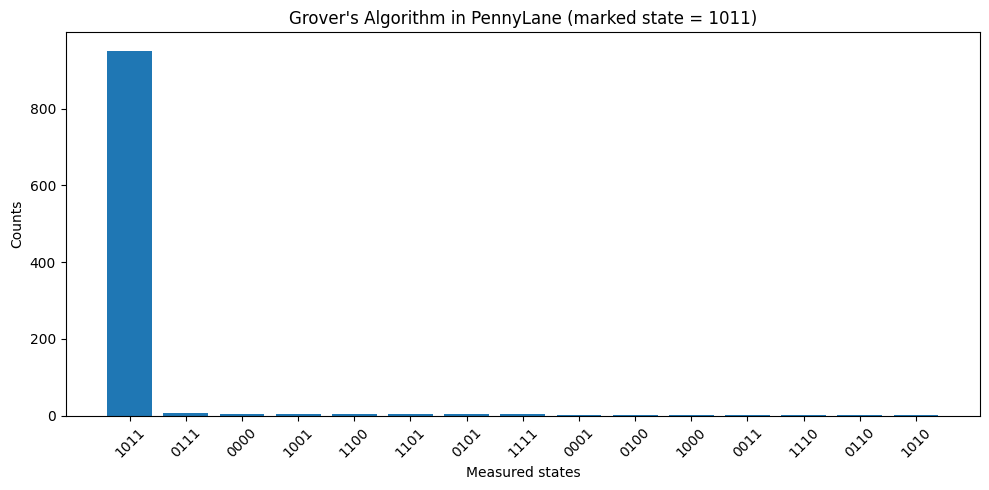

In [6]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
from math import floor, pi, sqrt

# --------------------------------------------------
# Configuration
# --------------------------------------------------
n_qubits = 4
marked_state = "1011"
shots = 1000

dev = qml.device("default.qubit", wires=n_qubits, shots=shots)


# --------------------------------------------------
# Oracle
# --------------------------------------------------
def oracle(marked_state):
    """
    Marks one basis state by flipping its phase.
    Example marked_state = '1011'
    """

    # Step 1: turn the marked state into |1111>
    # by applying X to qubits where the target bit is 0
    for i, bit in enumerate(marked_state):
        if bit == "0":
            qml.PauliX(wires=i)

    # Step 2: apply phase flip to |1111>
    # H - MCX - H turns the controlled-X into a phase flip
    qml.Hadamard(wires=3)
    qml.MultiControlledX(wires=[0, 1, 2, 3], control_values=[1, 1, 1])
    qml.Hadamard(wires=3)

    # Step 3: undo the X gates
    for i, bit in enumerate(marked_state):
        if bit == "0":
            qml.PauliX(wires=i)


# --------------------------------------------------
# Diffusion operator
# --------------------------------------------------
def diffusion():
    """
    Grover diffusion operator:
    H^n -> X^n -> phase flip on |1111> -> X^n -> H^n
    """

    # H on all qubits
    for i in range(n_qubits):
        qml.Hadamard(wires=i)

    # X on all qubits
    for i in range(n_qubits):
        qml.PauliX(wires=i)

    # Phase flip on |1111>
    qml.Hadamard(wires=3)
    qml.MultiControlledX(wires=[0, 1, 2, 3], control_values=[1, 1, 1])
    qml.Hadamard(wires=3)

    # X on all qubits
    for i in range(n_qubits):
        qml.PauliX(wires=i)

    # H on all qubits
    for i in range(n_qubits):
        qml.Hadamard(wires=i)


# --------------------------------------------------
# Number of Grover iterations
# --------------------------------------------------
N = 2 ** n_qubits
iterations = floor((pi / 4) * sqrt(N))


# --------------------------------------------------
# Full Grover circuit
# --------------------------------------------------
@qml.qnode(dev)
def grover_circuit():
    # 1. Initialization: equal superposition
    for i in range(n_qubits):
        qml.Hadamard(wires=i)

    # 2. Grover iterations
    for _ in range(iterations):
        oracle(marked_state)
        diffusion()

    # 3. Measure all qubits
    return qml.counts(wires=range(n_qubits))


# --------------------------------------------------
# Run the circuit
# --------------------------------------------------
result = grover_circuit()

print("Marked state:", marked_state)
print("Number of Grover iterations:", iterations)
print("\nMeasurement counts:")

sorted_result = dict(sorted(result.items(), key=lambda x: x[1], reverse=True))

for state, count in sorted_result.items():
    print(f"{state}: {count}")


# --------------------------------------------------
# Plot histogram
# --------------------------------------------------
states = list(sorted_result.keys())
counts = list(sorted_result.values())

plt.figure(figsize=(10, 5))
plt.bar(states, counts)
plt.xlabel("Measured states")
plt.ylabel("Counts")
plt.title(f"Grover's Algorithm in PennyLane (marked state = {marked_state})")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()